In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.sparse as sp
import time
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import implicit
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import scipy.sparse as sp
from scipy.sparse.linalg import svds

c:\Users\Admin\miniconda3\envs\smog\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Загрузка данных и знакомство с датасетом

## Загрузка

In [2]:
df = pd.read_json(r'data\Patio_Lawn_and_Garden_5.json', lines=True, compression='infer')

In [3]:
df.head(5)

,overall,vote,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,style,image
0,5,2,True,"12 11, 2011",AUVPE2KEXBJVT,9539723809,T. E. Kainz,I don't spend a lot on my flags because they r...,Good quality for the price,1323561600,NaN,NaN
1,5,NaN,True,"07 30, 2011",A2F6GES1MBOFXS,9539723809,BluesJamJim,"Super fast processing and shipping, if you are...",3'x5' Colorado State flag,1311984000,NaN,NaN
2,5,NaN,True,"05 4, 2016",A1SDVD3SZI1BAK,9539723809,Gabriel M Martinez,Great product. I would recommend this product...,Colorado Flag,1462320000,NaN,NaN
3,5,NaN,True,"11 2, 2015",A1ZQJ3KCSLUPR3,9539723809,RAJ THE FLASH,GREAT PRICE I LOVE MY STATE AND COUNTRY,RETIRED MILITARY,1446422400,NaN,NaN
4,5,NaN,True,"09 1, 2015",ANU8FBZM618M3,9539723809,James R. Mills,Great display flag for the den.,Five Stars,1441065600,NaN,NaN


## Базовый EDA

In [4]:
print("Количество строк:", len(df))
print("Уникальные пользователи:", df['reviewerID'].nunique())
print("Уникальные товары:", df['asin'].nunique())
print("Пропуски:\n", df.isnull().sum())

Количество строк: 798415
Уникальные пользователи: 103431
Уникальные товары: 32918
Пропуски:
 overall                0
vote              675373
verified               0
reviewTime             0
reviewerID             0
asin                   0
reviewerName          27
reviewText           186
summary              156
unixReviewTime         0
style             401768
image             782206
dtype: int64


In [5]:
# Разреженность матрицы user-item
n_users = df['reviewerID'].nunique()
n_items = df['asin'].nunique()
sparsity = 1 - len(df) / (n_users * n_items)
print(f"Sparsity: {sparsity:.6f}")


Sparsity: 0.999765



Распределение рейтингов:
 overall
1     51553
2     32392
3     57475
4    123392
5    533603
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_14332\1029850163.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")


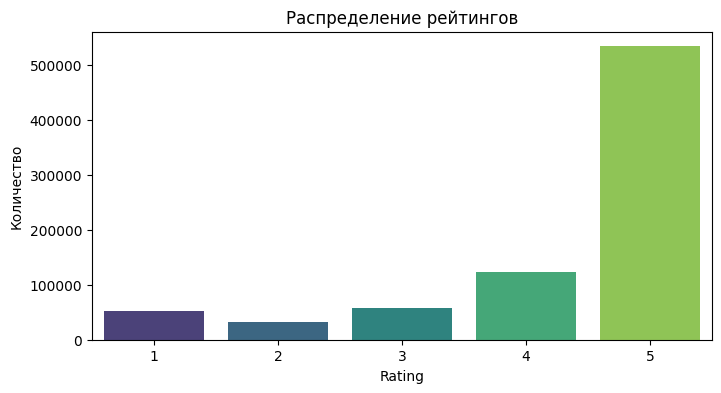

In [6]:
# Распределение рейтингов
rating_counts = df['overall'].value_counts().sort_index()
print("\nРаспределение рейтингов:\n", rating_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")
plt.title("Распределение рейтингов")
plt.xlabel("Rating")
plt.ylabel("Количество")
plt.show()

In [7]:
# Средний рейтинг
print("\nСредний рейтинг:", df['overall'].mean())

# Активность пользователей
user_counts = df.groupby('reviewerID').size()
print("\nКоличество оценок на пользователя:\n", user_counts.describe())


Средний рейтинг: 4.321493208419181

Количество оценок на пользователя:
 count    103431.000000
mean          7.719301
std           4.867808
min           2.000000
25%           5.000000
50%           6.000000
75%           8.000000
max         227.000000
dtype: float64


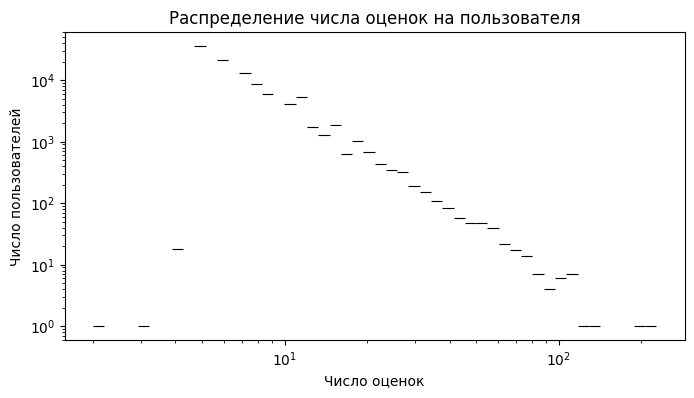

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(user_counts, bins=50, log_scale=(True, True))
plt.title("Распределение числа оценок на пользователя")
plt.xlabel("Число оценок")
plt.ylabel("Число пользователей")
plt.show()


Количество оценок на товар:
 count    32918.000000
mean        24.254663
std         52.397295
min          1.000000
25%          6.000000
50%         11.000000
75%         22.000000
max       2596.000000
dtype: float64


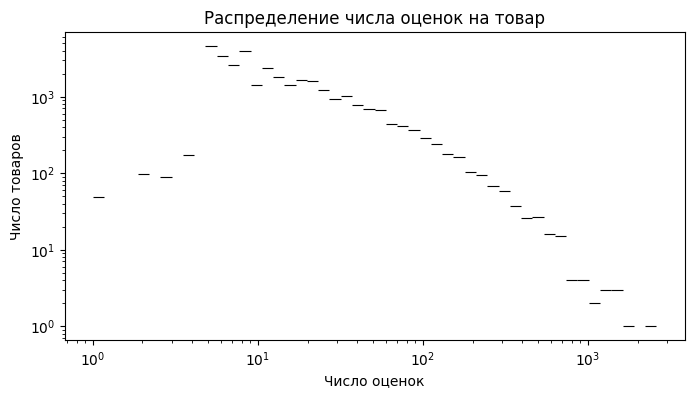

In [9]:
# Популярность товаров
item_counts = df.groupby('asin').size()
print("\nКоличество оценок на товар:\n", item_counts.describe())

plt.figure(figsize=(8, 4))
sns.histplot(item_counts, bins=50, log_scale=(True, True))
plt.title("Распределение числа оценок на товар")
plt.xlabel("Число оценок")
plt.ylabel("Число товаров")
plt.show()

In [10]:
# Временной диапазон
df['datetime'] = pd.to_datetime(df['unixReviewTime'], unit='s')
print("\nВременной диапазон:")
print("min:", df['datetime'].min())
print("max:", df['datetime'].max())


Временной диапазон:
min: 2000-03-15 00:00:00
max: 2018-10-03 00:00:00


# 2. Разбиение leave-one-out

In [11]:
def leave_one_out_split(
    df,
    user_col='reviewerID',
    timestamp_col='datetime'
):
    """
    Последняя запись каждого пользователя -> test,
    остальные -> train.
    """
    df = df.sort_values([user_col, timestamp_col]).copy()

    # последняя строка для каждого пользователя
    test = df.groupby(user_col).tail(1)
    test_idx = test.index

    train = df.drop(test_idx)

    return train, test


In [12]:
train, test = leave_one_out_split(df)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train users:", train['reviewerID'].nunique())
print("Test users:", test['reviewerID'].nunique())


Train shape: (694984, 13)
Test shape: (103431, 13)
Train users: 103431
Test users: 103431


In [13]:
# Проверка, что каждый тестовый пользователь есть в train
test_users_without_train = test[~test['reviewerID'].isin(train['reviewerID'])]['reviewerID'].nunique()
print("Тестовых пользователей без train-истории:", test_users_without_train)


Тестовых пользователей без train-истории: 0


# 3. Создание классов моделей

## 3.1 Вспомогательные функции

In [14]:
def hit_rate_at_k(reco_lists, test_items, k=10):
    """
    Calculate hit rate at k.
    """
    hits = 0
    for reco, true_item in zip(reco_lists, test_items):
        if true_item in reco[:k]:
            hits += 1
    return hits / len(test_items)

In [15]:
def mrr_at_k(reco_lists, test_items, k=10):
    """
    Calculate MRR@k for a list of recommendations.
    """
    rr_sum = 0.0
    for reco, true_item in zip(reco_lists, test_items):
        try:
            rank = reco[:k].index(true_item) + 1
            rr_sum += 1.0 / rank
        except ValueError:
            pass
    return rr_sum / len(test_items)

In [16]:
def ndcg_at_k(reco_lists, test_items, k=10):
    """
    Computes the Normalized Discounted Cumulative Gain (NDCG) at k.
    """
    dcg_sum = 0.0
    idcg = 1.0 / np.log2(2)  # один релевантный на первой позиции
    for reco, true_item in zip(reco_lists, test_items):
        if true_item in reco[:k]:
            rank = reco[:k].index(true_item) + 1
            dcg_sum += 1.0 / np.log2(rank + 1)
    return dcg_sum / len(test_items) / idcg

In [17]:
def coverage(reco_lists, catalog_size):
    """
    Computes the coverage of recommendations.
    """
    recommended_items = set()
    for reco in reco_lists:
        recommended_items.update(reco)
    return len(recommended_items) / catalog_size

## 3.2 Popularity baseline

In [18]:
class PopularityModel:
    def __init__(self, train_df, top_n=10):
        self.top_n = top_n
        self.popular_items = train_df['asin'].value_counts().index.tolist()[:200]  # берём 200 популярных

    def recommend(self, user_id, train_items, n=10):
        # исключаем уже купленные
        candidates = [i for i in self.popular_items if i not in train_items]
        return candidates[:n]

## 3.3 ALS (Implicit)


In [19]:
class ALSModel:
    def __init__(self, train_df, factors=50, regularization=0.1, iterations=20):
        self.factors = factors
        self.regularization = regularization
        self.iterations = iterations
        self.model = implicit.als.AlternatingLeastSquares(
            factors=self.factors,
            regularization=self.regularization,
            iterations=self.iterations,
            random_state=42
        )
        self._prepare(train_df)

    def _prepare(self, train_df):
        # кодируем reviewerID и asin
        self.user_encoder = {u: i for i, u in enumerate(train_df['reviewerID'].unique())}
        self.item_encoder = {i: idx for idx, i in enumerate(train_df['asin'].unique())}
        self.item_decoder = {idx: i for i, idx in self.item_encoder.items()}

        rows = train_df['reviewerID'].map(self.user_encoder).values
        cols = train_df['asin'].map(self.item_encoder).values
        ratings = train_df['overall'].values.astype(np.float32)
        self.user_item_matrix = csr_matrix((ratings, (rows, cols)),
                                           shape=(len(self.user_encoder), len(self.item_encoder)))

    def fit(self):
        start = time.time()
        self.model.fit(self.user_item_matrix)
        self.train_time = time.time() - start

    def recommend(self, user_id, train_items, n=10):
        if user_id not in self.user_encoder:
            return []
        user_idx = self.user_encoder[user_id]
        result = self.model.recommend(
            user_idx, self.user_item_matrix[user_idx], N=n, filter_already_liked_items=True
        )
        
        # Обработка результата в зависимости от версии implicit
        if isinstance(result, tuple) and len(result) == 2:
            # новая версия: (item_ids_array, scores_array)
            item_ids, _ = result
            item_ids = [int(i) for i in item_ids]
        else:
            # старая версия: список кортежей [(id, score), ...]
            item_ids = [int(i) for i, _ in result]
        
        # Дополнительная фильтрация (на случай, если модель не отфильтровала)
        train_set = set(train_items) if not isinstance(train_items, set) else train_items
        filtered_ids = []
        for i in item_ids:
            if i in self.item_decoder and self.item_decoder[i] not in train_set:
                filtered_ids.append(self.item_decoder[i])
        return filtered_ids

## 3.4 Item‑Item Collaborative Filtering (Implicit)

In [20]:
class ItemItemCFModel:
    def __init__(self, train_df, k=50):
        self.k = k
        self.model = implicit.nearest_neighbours.ItemItemRecommender(K=k)
        self._prepare(train_df)

    def _prepare(self, train_df):
        self.user_encoder = {u: i for i, u in enumerate(train_df['reviewerID'].unique())}
        self.item_encoder = {i: idx for idx, i in enumerate(train_df['asin'].unique())}
        self.item_decoder = {idx: i for i, idx in self.item_encoder.items()}
        rows = train_df['reviewerID'].map(self.user_encoder).values
        cols = train_df['asin'].map(self.item_encoder).values
        ratings = train_df['overall'].values.astype(np.float64)
    
        self.user_item_matrix = csr_matrix((ratings, (rows, cols)),
                                           shape=(len(self.user_encoder), len(self.item_encoder)))

    def fit(self):
        start = time.time()
        self.model.fit(self.user_item_matrix)
        self.train_time = time.time() - start

    def recommend(self, user_id, train_items, n=10):
        if user_id not in self.user_encoder:
            return []
        user_idx = self.user_encoder[user_id]
        result = self.model.recommend(
            user_idx, self.user_item_matrix[user_idx], N=n, filter_already_liked_items=True
        )
        
        if isinstance(result, tuple) and len(result) == 2:
            item_ids, _ = result
            item_ids = [int(i) for i in item_ids]
        else:
            item_ids = [int(i) for i, _ in result]
        
        train_set = set(train_items) if not isinstance(train_items, set) else train_items
        filtered_ids = []
        for i in item_ids:
            if i in self.item_decoder and self.item_decoder[i] not in train_set:
                filtered_ids.append(self.item_decoder[i])
        return filtered_ids

## 3.5 SVD (оптимизированный для разреженных данных)

In [21]:
class SVDModel:
    def __init__(self, train_df, n_factors=50):
        self.n_factors = n_factors
        self._prepare(train_df)

    def _prepare(self, train_df):
        self.user_encoder = {u: i for i, u in enumerate(train_df['reviewerID'].unique())}
        self.item_encoder = {i: idx for idx, i in enumerate(train_df['asin'].unique())}
        self.item_decoder = {idx: i for i, idx in self.item_encoder.items()}

        # Центрирование рейтингов: вычитаем глобальное среднее
        self.global_mean = train_df['overall'].mean()
        rows = train_df['reviewerID'].map(self.user_encoder).values
        cols = train_df['asin'].map(self.item_encoder).values
        ratings_centered = train_df['overall'].values - self.global_mean

        self.user_item_matrix = csr_matrix(
            (ratings_centered, (rows, cols)),
            shape=(len(self.user_encoder), len(self.item_encoder))
        )

    def fit(self):
        start = time.time()
        # svds ожидает матрицу, где строки – пользователи, столбцы – товары.
        # Возвращает u (n_users × k), s (k,), vt (k × n_items)
        u, s, vt = svds(self.user_item_matrix, k=self.n_factors)
        self.user_factors = u @ np.diag(s)   # (n_users × k)
        self.item_factors = vt.T             # (n_items × k)
        self.train_time = time.time() - start

    def recommend(self, user_id, train_history, n=10):
        if user_id not in self.user_encoder:
            return []
        user_idx = self.user_encoder[user_id]
        # Предсказание: пользовательский фактор × товарные факторы + глобальное среднее
        scores = self.user_factors[user_idx] @ self.item_factors.T + self.global_mean

        train_set = set(train_history.keys())
        candidates = []
        for item_idx, score in enumerate(scores):
            item_id = self.item_decoder.get(item_idx)
            if item_id and item_id not in train_set:
                candidates.append((score, item_id))
        candidates.sort(key=lambda x: x[0], reverse=True)
        return [item_id for _, item_id in candidates[:n]]

## 3.6 Гибридная модель

In [34]:
class HybridModel:
    def __init__(self, recos_list, weights, user_list):
        """
        recos_list: список списков рекомендаций для всех пользователей (по моделям)
        weights: веса моделей
        user_list: список user_id в том же порядке, что и в recos_list
        """
        self.recos_list = recos_list
        self.weights = weights
        self.user_to_idx = {u: i for i, u in enumerate(user_list)}

    def recommend(self, user_id, train_items, n=10):
        if user_id not in self.user_to_idx:
            return []
        idx = self.user_to_idx[user_id]
        scores = {}
        for recos_all, w in zip(self.recos_list, self.weights):
            recos = recos_all[idx]   # список рекомендаций для данного пользователя
            if not recos:
                continue
            max_score = len(recos)
            for rank, item in enumerate(recos):
                score = (max_score - rank) / max_score
                scores[item] = scores.get(item, 0) + w * score
        sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        filtered = [i for i, s in sorted_items if i not in train_items]
        return filtered[:n]

# 4. Обучение моделей и оценка

In [23]:
# Готовим списки для теста
test_users = test['reviewerID'].tolist()
test_items = test['asin'].tolist()

# Для быстрой проверки train_items для каждого пользователя
user_train_items = train.groupby('reviewerID')['asin'].apply(set).to_dict()

In [24]:
# ---------- 1. Popularity ----------
print("Training Popularity...")
pop_model = PopularityModel(train)
pop_train_time = 0.0  # не требует обучения
pop_recos = [pop_model.recommend(u, user_train_items.get(u, set()), n=10) for u in test_users]

Training Popularity...


In [25]:
# ---------- 2. ALS ----------
print("Training ALS...")
als_model = ALSModel(train, factors=50, regularization=0.1, iterations=15)
als_model.fit()
als_recos = []
for u in test_users:
    als_recos.append(als_model.recommend(u, user_train_items.get(u, set()), n=10))

Training ALS...


c:\Users\Admin\miniconda3\envs\smog\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 20 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 15/15 [00:03<00:00,  4.31it/s]


In [26]:
# ---------- 3. Item-Item CF ----------
print("Training ItemItem CF...")
cf_model = ItemItemCFModel(train, k=50)
cf_model.fit()
cf_recos = []
for u in test_users:
    cf_recos.append(cf_model.recommend(u, user_train_items.get(u, set()), n=10))

Training ItemItem CF...


100%|██████████| 32894/32894 [00:00<00:00, 242815.34it/s]


In [27]:
# ---------- 4. SVD ----------
user_train_history = (
    train.groupby('reviewerID')
        .apply(lambda x: dict(zip(x['reviewerID'], x['overall'])))
        .to_dict()
)
print("Training SVD...")
svd_model = SVDModel(train, n_factors=50)
svd_model.fit()

svd_recos = []
for u in test_users:
    hist = user_train_history.get(u, {})
    recos = svd_model.recommend(u, hist, n=10)
    svd_recos.append(recos)

C:\Users\Admin\AppData\Local\Temp\ipykernel_14332\2575541221.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: dict(zip(x['reviewerID'], x['overall'])))


Training SVD...


In [35]:
# ---------- 5. Hybrid ----------
print("Building Hybrid...")
hybrid_model = HybridModel(
    recos_list=[pop_recos, als_recos, cf_recos, svd_recos],
    weights=[0.1, 0.4, 0.3, 0.2],
    user_list=test_users
)

hybrid_recos = []
for u in test_users:
    hist = user_train_history.get(u, {})
    hybrid_recos.append(hybrid_model.recommend(u, hist, n=10))

Building Hybrid...


# 5. Оценка метрик

In [36]:
# Число уникальных товаров в train (для coverage)
catalog_size = train['asin'].nunique()

models_results = {
    'Popularity': pop_recos,
    'ALS': als_recos,
    'ItemItem CF': cf_recos,
    'SVD': svd_recos,
    'Hybrid': hybrid_recos
}

results = []
for name, recos in models_results.items():
    hr = hit_rate_at_k(recos, test_items, k=10)
    mrr = mrr_at_k(recos, test_items, k=10)
    ndcg = ndcg_at_k(recos, test_items, k=10)
    cov = coverage(recos, catalog_size)
    # время обучения
    if name == 'Popularity':
        train_time = pop_train_time
    elif name == 'ALS':
        train_time = als_model.train_time
    elif name == 'ItemItem CF':
        train_time = cf_model.train_time
    elif name == 'Content':
        train_time = 0.0  # подготовка признаков была быстрой
    elif name == 'Hybrid':
        train_time = 0.0  # нет отдельного обучения
    results.append({
        'Model': name,
        'HR@10': hr,
        'MRR@10': mrr,
        'NDCG@10': ndcg,
        'Coverage': cov,
        'Train Time (s)': train_time
    })

results_df = pd.DataFrame(results)
print("\n=== Сводная таблица ===")
display(results_df)


=== Сводная таблица ===


,Model,HR@10,MRR@10,NDCG@10,Coverage,Train Time (s)
0,Popularity,0.003007,0.000700,0.001240,0.000456,0.000000
1,ALS,0.030948,0.014584,0.018396,0.023165,3.499480
2,ItemItem CF,0.054307,0.029807,0.035570,0.443759,0.198978
3,SVD,0.013052,0.007865,0.009111,0.026114,0.198978
4,Hybrid,0.050275,0.018717,0.025959,0.244938,0.000000


C:\Users\Admin\AppData\Local\Temp\ipykernel_14332\5374744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_14332\5374744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_14332\5374744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\Admin\AppData\Lo

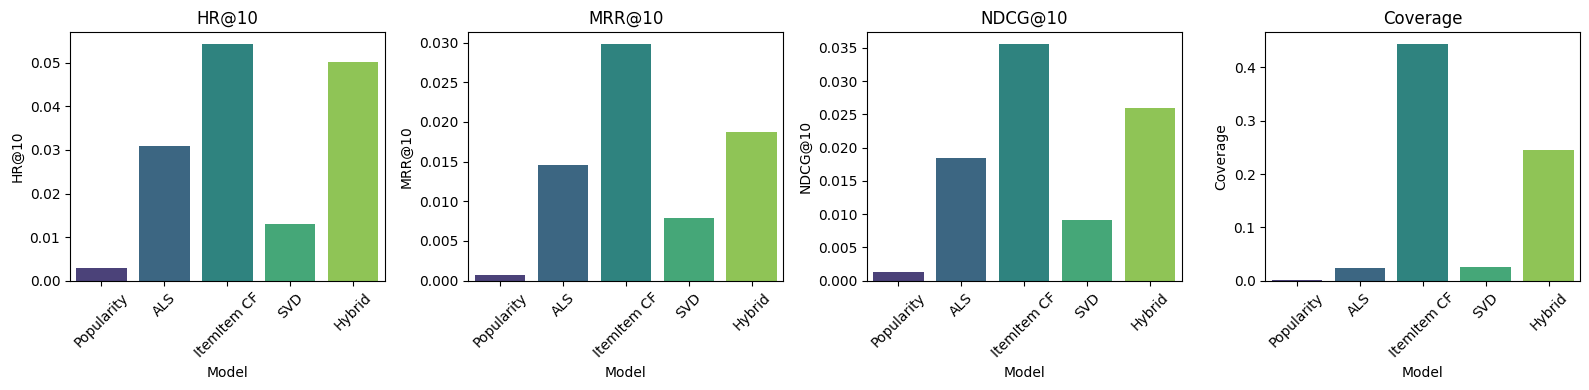

C:\Users\Admin\AppData\Local\Temp\ipykernel_14332\5374744.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Train Time (s)', palette='magma')


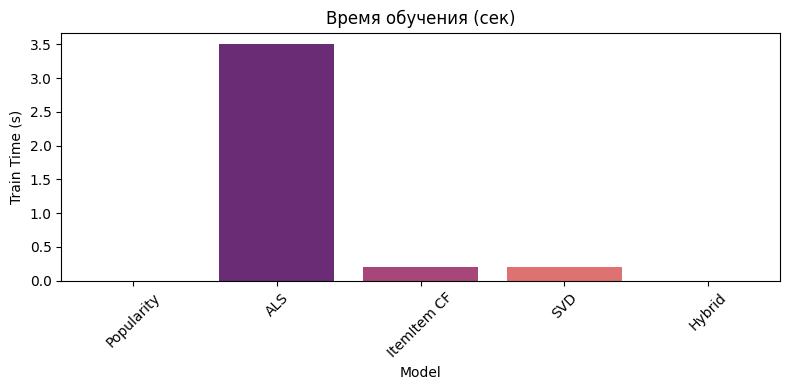

In [37]:
# Графики метрик
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['HR@10', 'MRR@10', 'NDCG@10', 'Coverage']
for ax, metric in zip(axes, metrics):
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax, palette='viridis')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Время обучения
plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x='Model', y='Train Time (s)', palette='magma')
plt.title('Время обучения (сек)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
